In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned/telco_customer_churn_cleaned.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["ChurnFlag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [4]:
churn_rate = df["ChurnFlag"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


In [5]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: ChurnFlag, dtype: float64

In [6]:
internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

internet_churn

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: ChurnFlag, dtype: float64

In [7]:
payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: ChurnFlag, dtype: float64

In [8]:
df.groupby("Churn")["tenure"].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

In [9]:
df.groupby("Churn")["MonthlyCharges"].mean().round(2)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

In [10]:
df.groupby("Churn")["TotalCharges"].mean().round(2)

Churn
No     2549.91
Yes    1531.80
Name: TotalCharges, dtype: float64

In [11]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=["0-12 months", "13-24 months", "25-48 months",
            "49-60 months", "61-72 months"]
)

In [12]:
tenure_churn = (
    df.groupby("TenureGroup", observed=False)["ChurnFlag"]
    .mean()
    .mul(100)
    .round(2)
)

tenure_churn

TenureGroup
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-60 months    14.42
61-72 months     6.61
Name: ChurnFlag, dtype: float64

Matplotlib is building the font cache; this may take a moment.


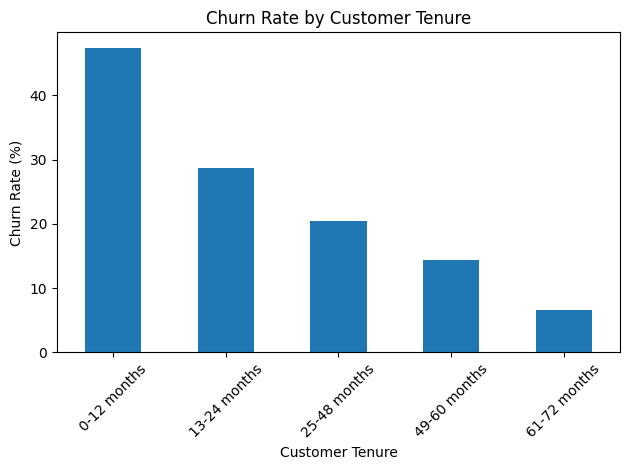

In [13]:
import matplotlib.pyplot as plt

tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: ChurnFlag, dtype: float64

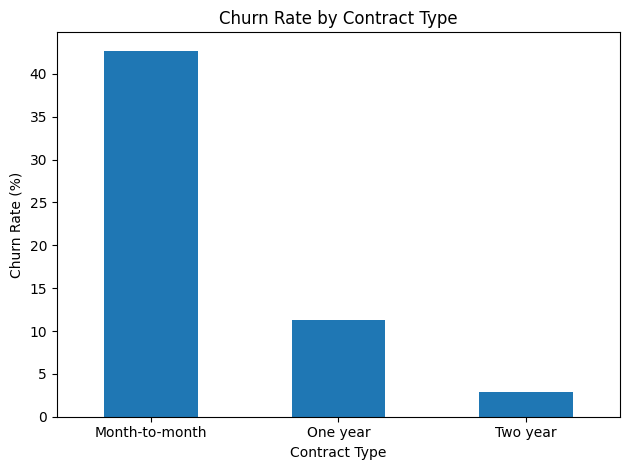

In [15]:
contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

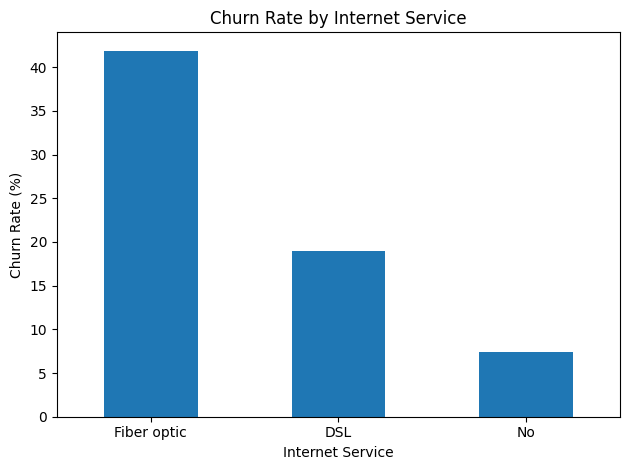

In [16]:
internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

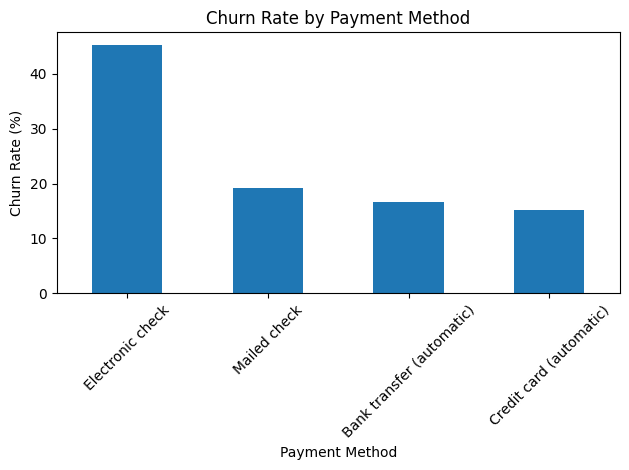

In [17]:
payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Business Insights

The analysis identified several customer characteristics strongly associated with churn:

1. **Overall Churn**
   - The overall customer churn rate is 26.54%.

2. **Customer Tenure**
   - New customers have the highest churn risk.
   - Customers with 0–12 months of tenure have a churn rate of 47.44%.
   - Churn decreases steadily as customer tenure increases, reaching only 6.61% for customers with 61–72 months of tenure.

3. **Contract Type**
   - Month-to-month customers have substantially higher churn than customers with one-year or two-year contracts.
   - Longer-term contracts are associated with significantly better customer retention.

4. **Internet Service**
   - Fiber optic customers have the highest churn rate at 41.89%.
   - DSL customers have a considerably lower churn rate of 18.96%.

5. **Payment Method**
   - Customers using electronic checks have the highest churn rate at 45.29%.
   - Customers using automatic payment methods have substantially lower churn rates.

## Business Recommendations

Based on the churn analysis, the following actions could help improve customer retention:

1. **Focus retention efforts on new customers**
   - Customers in their first 12 months have the highest churn rate (47.44%).
   - Introduce stronger onboarding, early customer support, and targeted retention offers during the first year.

2. **Encourage longer-term contracts**
   - Month-to-month customers have substantially higher churn than customers on one-year and two-year contracts.
   - Offer incentives or discounts for customers who switch from month-to-month to longer-term contracts.

3. **Investigate fiber optic customer experience**
   - Fiber optic customers have a churn rate of 41.89%, significantly higher than DSL customers.
   - Investigate service quality, pricing, reliability, and customer satisfaction among fiber optic customers.

4. **Promote automatic payment methods**
   - Customers paying by electronic check have the highest churn rate (45.29%).
   - Encourage customers to use automatic bank transfers or credit card payments where appropriate.

5. **Develop a targeted retention strategy**
   - Use tenure, contract type, internet service, and payment method to identify customer segments with elevated churn risk.
   - Prioritize retention campaigns toward customers who exhibit multiple high-risk characteristics.